# 실험 1: ResNet50 이진 분류 + XAI 히트맵 생성

RetinaVLM의 SSL pretrained ResNet50을 사용하여 이진 분류를 수행하고,
다양한 XAI 기법으로 히트맵을 생성합니다.

**IRB 프로토콜 역할:**
- ResNet50 visual encoder의 판단 근거를 GradCAM 등으로 시각화
- 생성된 XAI 히트맵은 **실험 3 (Setting B)**에서 이미지 오버레이로 주입됨
- 향후 전문의 어노테이션과의 IoU 비교를 위한 기준 히트맵 역할

**파이프라인:**
1. OCT 데이터셋 로드 (현재: NORMAL vs CNV, 향후: Responder vs Non-responder)
2. ResNet50 backbone (frozen) + classification head 학습
3. 성능 평가 (Accuracy, Precision, Recall, F1, ROC-AUC)
4. XAI 히트맵 생성 (GradCAM, GradCAM++, EigenCAM, LayerCAM)
5. XAI 이미지 + NPY 저장 → 실험 3에서 사용

## 1. Imports & 설정

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import os, sys, time, json, copy
from PIL import Image
from glob import glob
from collections import Counter
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_fscore_support)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# SpecialistVLMs 모듈 경로 추가 (ResNet50 backbone용)
SPECIALIST_DIR = os.path.abspath("../SpecialistVLMs")
if SPECIALIST_DIR not in sys.path:
    sys.path.insert(0, SPECIALIST_DIR)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. 실험 파라미터 (여기만 수정)

In [3]:
# =====================================================
#  실험 파라미터
# =====================================================

# 데이터셋 경로 (끝에 공백 주의!)
DATA_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 "

# RetinaVLM 체크포인트 (ResNet50 가중치 추출용)
RETINAVLM_CKPT = os.path.join(SPECIALIST_DIR, "saved_models/RetinaVLM-Specialist-Dequantized/model.pt")

# =====================================================
#  분류 레이블 설정
# =====================================================
# 현재: OCT2017 데모 데이터 (NORMAL vs CNV)
CLASS_NAMES = ["NORMAL", "CNV"]
NUM_CLASSES = 2
# 향후 병원 데이터 적용 시:
# CLASS_NAMES = ["Responder", "Non-responder"]
# DATA_DIR = "/path/to/hospital/oct_data"

# 학습 파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224
MAX_TRAIN_PER_CLASS = 2000   # 클래스당 최대 학습 이미지 (None=전체)
MAX_TEST_PER_CLASS = None    # 테스트는 전체 사용 (242장씩)

# XAI 설정
XAI_METHODS = ["gradcam", "gradcam++", "eigencam", "layercam"]
N_XAI_SAMPLES = 50          # XAI 히트맵 생성할 테스트 이미지 수 (per class)

# 출력 디렉토리
OUTPUT_DIR = "exp1_outputs"
XAI_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "xai_images")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(XAI_OUTPUT_DIR, exist_ok=True)

# XAI 기법별 하위 폴더 생성
for method in XAI_METHODS:
    os.makedirs(os.path.join(XAI_OUTPUT_DIR, method), exist_ok=True)

print(f"Data dir: {DATA_DIR}")
print(f"Checkpoint: {RETINAVLM_CKPT}")
print(f"Classes: {CLASS_NAMES}")
print(f"Output: {OUTPUT_DIR}")
print(f"XAI output: {XAI_OUTPUT_DIR}")
print(f"\n** 히트맵은 실험 3 (Setting B)에서 이미지 오버레이로 사용됩니다 **")

Data dir: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 
Checkpoint: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/saved_models/RetinaVLM-Specialist-Dequantized/model.pt
Classes: ['NORMAL', 'CNV']
Output: exp1_outputs
XAI output: exp1_outputs/xai_images

** 히트맵은 실험 3 (Setting B)에서 이미지 오버레이로 사용됩니다 **


## 3. 데이터셋 준비 (NORMAL vs CNV 이진 분류)

In [4]:
class OCTBinaryDataset(Dataset):
    """NORMAL(0) vs CNV(1) 이진 분류 데이터셋."""
    def __init__(self, root_dir, transform=None, max_per_class=None):
        self.transform = transform
        self.samples = []  # (path, label)

        for label, cls_name in enumerate(CLASS_NAMES):
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_dir):
                raise FileNotFoundError(f"Class dir not found: {cls_dir}")

            files = sorted(glob(os.path.join(cls_dir, "*.jpeg")) +
                          glob(os.path.join(cls_dir, "*.jpg")) +
                          glob(os.path.join(cls_dir, "*.png")))

            if max_per_class and len(files) > max_per_class:
                step = len(files) / max_per_class
                files = [files[int(i * step)] for i in range(max_per_class)]

            for f in files:
                self.samples.append((f, label))

        print(f"  Loaded {len(self.samples)} images from {root_dir}")
        for label, cls_name in enumerate(CLASS_NAMES):
            n = sum(1 for _, l in self.samples if l == label)
            print(f"    {cls_name} (label={label}): {n} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        return img, label, path


# Transforms
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

# 데이터셋 로드
train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

print("=== Train Dataset ===")
train_ds = OCTBinaryDataset(train_dir, train_tf, MAX_TRAIN_PER_CLASS)
print("\n=== Test Dataset ===")
test_ds = OCTBinaryDataset(test_dir, val_tf, MAX_TEST_PER_CLASS)

# DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}, Test batches: {len(test_loader)}")

=== Train Dataset ===
  Loaded 4000 images from /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 /train
    NORMAL (label=0): 2000 images
    CNV (label=1): 2000 images

=== Test Dataset ===
  Loaded 484 images from /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 /test
    NORMAL (label=0): 242 images
    CNV (label=1): 242 images

Train batches: 125, Test batches: 16


## 4. ResNet50 모델 구성 (RetinaVLM 체크포인트)

In [5]:
from models.ssl_config import ssl_backbone

class ResNet50BinaryClassifier(nn.Module):
    """RetinaVLM SSL pretrained ResNet50 + binary classification head."""
    def __init__(self, checkpoint_path=None):
        super().__init__()
        # ResNet50 backbone (1채널 입력)
        self.backbone = ssl_backbone(channels_in=1, blocks=[3, 4, 6, 3])
        self.feature_dim = 2048

        # 체크포인트에서 backbone 가중치 로드
        if checkpoint_path and os.path.exists(checkpoint_path):
            print(f"Loading ResNet50 weights from: {checkpoint_path}")
            sd = torch.load(checkpoint_path, map_location="cpu")

            resnet_sd = {}
            prefix = "model.visual_encoder.model."
            for k, v in sd.items():
                if k.startswith(prefix):
                    resnet_sd[k[len(prefix):]] = v

            if len(resnet_sd) == 0:
                prefix = "visual_encoder.model."
                for k, v in sd.items():
                    if k.startswith(prefix):
                        resnet_sd[k[len(prefix):]] = v

            missing, unexpected = self.backbone.load_state_dict(resnet_sd, strict=False)
            print(f"  Loaded {len(resnet_sd)} keys | Missing: {len(missing)} | Unexpected: {len(unexpected)}")
            del sd
        else:
            print("WARNING: No checkpoint, using random init!")

        # Backbone freeze
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone.eval()

        # Binary classification head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, NUM_CLASSES),
        )

        trainable = sum(p.numel() for p in self.head.parameters())
        total = sum(p.numel() for p in self.parameters())
        print(f"  Total params: {total:,} | Trainable (head only): {trainable:,}")

    def forward(self, x):
        with torch.no_grad():
            features = self._extract_features(x)
        return self.head(features)

    def _extract_features(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        return x


# 모델 생성
model = ResNet50BinaryClassifier(RETINAVLM_CKPT).to(DEVICE)
print(f"\nModel ready on {DEVICE}")

Loading ResNet50 weights from: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/saved_models/RetinaVLM-Specialist-Dequantized/model.pt
  Loaded 318 keys | Missing: 0 | Unexpected: 0
  Total params: 24,026,818 | Trainable (head only): 525,058

Model ready on cuda


## 5. 학습

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    model.backbone.eval()  # backbone은 항상 eval

    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = logits.max(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    running_loss, total = 0.0, 0
    criterion = nn.CrossEntropyLoss()

    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)

        running_loss += loss.item() * imgs.size(0)
        _, preds = logits.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # CNV 확률
        total += imgs.size(0)

    return running_loss / total, all_preds, all_labels, all_probs


# 학습 실행
head_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(head_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_acc, best_state = 0.0, None

print(f"{'='*60}")
print(f" Training ResNet50 Binary Classifier ({NUM_EPOCHS} epochs)")
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, test_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        marker = " *best*"

    elapsed = time.time() - t0
    print(f"  [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"{elapsed:.1f}s{marker}")

# best weights 복원
if best_state:
    model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_acc:.4f}")

# 모델 저장
torch.save(best_state, os.path.join(OUTPUT_DIR, "resnet50_binary_best.pt"))
print(f"Model saved to {OUTPUT_DIR}/resnet50_binary_best.pt")

 Training ResNet50 Binary Classifier (15 epochs)
  [ 1/15] train_loss=0.2868 train_acc=0.8880 | val_loss=0.0476 val_acc=0.9959 | 23.8s *best*
  [ 2/15] train_loss=0.1349 train_acc=0.9540 | val_loss=0.0332 val_acc=0.9979 | 4.0s *best*
  [ 3/15] train_loss=0.1251 train_acc=0.9570 | val_loss=0.0210 val_acc=0.9979 | 3.8s
  [ 4/15] train_loss=0.1060 train_acc=0.9675 | val_loss=0.0277 val_acc=0.9959 | 3.8s
  [ 5/15] train_loss=0.0969 train_acc=0.9690 | val_loss=0.0173 val_acc=0.9979 | 3.8s
  [ 6/15] train_loss=0.0935 train_acc=0.9673 | val_loss=0.0135 val_acc=0.9979 | 4.1s
  [ 7/15] train_loss=0.0848 train_acc=0.9728 | val_loss=0.0127 val_acc=1.0000 | 4.8s *best*
  [ 8/15] train_loss=0.0818 train_acc=0.9710 | val_loss=0.0108 val_acc=1.0000 | 4.6s
  [ 9/15] train_loss=0.0783 train_acc=0.9742 | val_loss=0.0113 val_acc=1.0000 | 4.4s
  [10/15] train_loss=0.0828 train_acc=0.9742 | val_loss=0.0097 val_acc=1.0000 | 4.7s
  [11/15] train_loss=0.0823 train_acc=0.9728 | val_loss=0.0127 val_acc=1.0000 |

## 6. 성능 평가

 Classification Report
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       242
         CNV       1.00      1.00      1.00       242

    accuracy                           1.00       484
   macro avg       1.00      1.00      1.00       484
weighted avg       1.00      1.00      1.00       484


Binary Metrics (CNV=positive):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  ROC-AUC:   1.0000


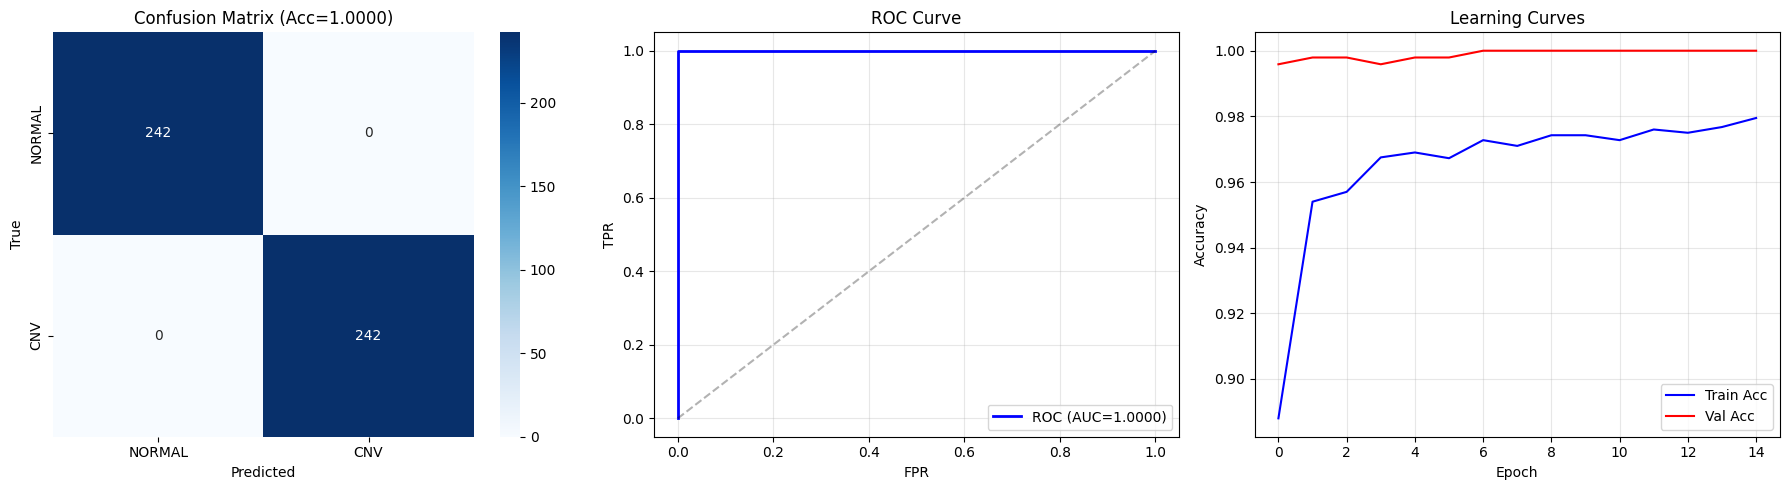


Metrics saved to exp1_outputs/metrics.json


In [7]:
# 최종 평가
val_loss, val_preds, val_labels, val_probs = evaluate(model, test_loader)
val_acc = accuracy_score(val_labels, val_preds)

# Classification Report
print("=" * 60)
print(" Classification Report")
print("=" * 60)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

# Precision, Recall, F1
precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels, val_preds, average="binary", pos_label=1)
roc_auc = roc_auc_score(val_labels, val_probs)

print(f"\nBinary Metrics (CNV=positive):")
print(f"  Accuracy:  {val_acc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# 시각화: Confusion Matrix + ROC Curve + Learning Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title(f"Confusion Matrix (Acc={val_acc:.4f})")

# ROC Curve
fpr, tpr, _ = roc_curve(val_labels, val_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning Curves
axes[2].plot(history["train_acc"], "b-", label="Train Acc")
axes[2].plot(history["val_acc"], "r-", label="Val Acc")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Learning Curves"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evaluation.png"), dpi=150, bbox_inches="tight")
plt.show()

# 메트릭 저장
metrics = {
    "accuracy": round(val_acc, 4), "precision": round(precision, 4),
    "recall": round(recall, 4), "f1": round(f1, 4), "roc_auc": round(roc_auc, 4),
    "confusion_matrix": cm.tolist(), "best_epoch_acc": round(best_acc, 4),
}
with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved to {OUTPUT_DIR}/metrics.json")

## 7. XAI 히트맵 생성 & 저장

**저장 규칙:** 원본 이미지와 1:1 매칭
- 원본: `CNV-1016042-1.jpeg`
- XAI:  `xai_images/gradcam/CNV-1016042-1_gradcam.png`
- XAI:  `xai_images/gradcam++/CNV-1016042-1_gradcam++.png`
- ...

나중에 LLM에 입력할 때 파일명으로 매칭합니다.

In [8]:
import torch.nn.functional as F

# ── XAI용 래퍼 (backbone에도 gradient 흐르도록) ──
class ResNet50ForXAI(nn.Module):
    def __init__(self, orig_model):
        super().__init__()
        self.backbone = orig_model.backbone
        self.head = orig_model.head

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        return self.head(x)


# ── GradCAM 추출기 ──
class GradCAMExtractor:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o): self.activations = o.detach()
    def _save_grad(self, m, gi, go): self.gradients = go[0].detach()

    def generate(self, input_tensor, target_class=None, method="gradcam"):
        self.model.eval()
        input_tensor = input_tensor.requires_grad_(True)
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        grads = self.gradients
        acts = self.activations

        if method == "gradcam":
            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam = (weights * acts).sum(dim=1, keepdim=True)
        elif method == "gradcam++":
            g2 = grads ** 2
            g3 = grads ** 3
            sum_acts = acts.sum(dim=(2, 3), keepdim=True)
            alpha = g2 / (2 * g2 + sum_acts * g3 + 1e-7)
            weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
            cam = (weights * acts).sum(dim=1, keepdim=True)
        elif method == "eigencam":
            B, C, H, W = acts.shape
            acts_2d = acts.reshape(C, H * W)
            _, _, Vh = torch.linalg.svd(acts_2d, full_matrices=False)
            cam = Vh[0:1, :].reshape(1, 1, H, W)
        elif method == "layercam":
            weights = F.relu(grads)
            cam = (weights * acts).sum(dim=1, keepdim=True)
        else:
            raise ValueError(f"Unknown method: {method}")

        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        probs = output.softmax(dim=1)[0].detach().cpu().numpy()
        return cam.cpu().numpy(), target_class, probs


# ── 모델 준비 ──
model_xai = ResNet50ForXAI(model).to(DEVICE).eval()
extractor = GradCAMExtractor(model_xai, model_xai.backbone.layer4)
print("XAI extractor ready (target: backbone.layer4)")

XAI extractor ready (target: backbone.layer4)


In [9]:
# ── 테스트셋에서 XAI 이미지 생성 & 저장 ──

# XAI용 데이터셋 (transform 없이 원본 크기도 함께 가져옴)
xai_ds = OCTBinaryDataset(test_dir, val_tf, N_XAI_SAMPLES)

print(f"Generating XAI heatmaps for {len(xai_ds)} images x {len(XAI_METHODS)} methods...")
print(f"Saving to: {XAI_OUTPUT_DIR}/")
print("-" * 60)

xai_log = []

for idx in range(len(xai_ds)):
    img_tensor, label, img_path = xai_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    raw_img = img_tensor.squeeze().numpy()
    fname_base = os.path.splitext(os.path.basename(img_path))[0]
    true_cls = CLASS_NAMES[label]

    entry = {"image": os.path.basename(img_path), "true_label": true_cls, "xai_files": {}}

    for method in XAI_METHODS:
        cam, pred_class, probs = extractor.generate(input_tensor, method=method)
        pred_cls = CLASS_NAMES[pred_class]

        # 히트맵 이미지 저장 (원본 + overlay)
        save_name = f"{fname_base}_{method}.png"
        save_path = os.path.join(XAI_OUTPUT_DIR, method, save_name)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # 원본
        axes[0].imshow(raw_img, cmap="gray")
        axes[0].set_title(f"Original ({true_cls})", fontsize=10)
        axes[0].axis("off")

        # 히트맵 단독
        axes[1].imshow(cam, cmap="jet")
        axes[1].set_title(f"{method} heatmap", fontsize=10)
        axes[1].axis("off")

        # 오버레이
        axes[2].imshow(raw_img, cmap="gray")
        axes[2].imshow(cam, cmap="jet", alpha=0.5)
        axes[2].set_title(f"Pred: {pred_cls} ({probs[pred_class]:.2f})", fontsize=10)
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()

        # 히트맵 raw 데이터도 저장 (npy) - LLM 텍스트 설명 생성용
        npy_path = os.path.join(XAI_OUTPUT_DIR, method, f"{fname_base}_{method}.npy")
        np.save(npy_path, cam)

        entry["xai_files"][method] = save_name
        entry["pred_label"] = pred_cls
        entry["pred_probs"] = {CLASS_NAMES[i]: round(float(probs[i]), 4) for i in range(NUM_CLASSES)}

    xai_log.append(entry)

    if (idx + 1) % 20 == 0 or idx == 0:
        print(f"  [{idx+1}/{len(xai_ds)}] {fname_base} | True: {true_cls} | Pred: {pred_cls}")

# XAI 로그 저장 (이미지-XAI 매핑 정보)
xai_log_path = os.path.join(XAI_OUTPUT_DIR, "xai_mapping.json")
with open(xai_log_path, "w") as f:
    json.dump(xai_log, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"XAI 생성 완료!")
print(f"  총 이미지: {len(xai_log)}")
print(f"  총 히트맵: {len(xai_log) * len(XAI_METHODS)}")
print(f"  매핑 로그: {xai_log_path}")
for method in XAI_METHODS:
    n = len(os.listdir(os.path.join(XAI_OUTPUT_DIR, method))) // 2  # png + npy
    print(f"  {method}: {n} files")

  Loaded 100 images from /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 /test
    NORMAL (label=0): 50 images
    CNV (label=1): 50 images
Generating XAI heatmaps for 100 images x 4 methods...
Saving to: exp1_outputs/xai_images/
------------------------------------------------------------
  [1/100] NORMAL-1017237-1 | True: NORMAL | Pred: NORMAL
  [20/100] NORMAL-2549549-1 | True: NORMAL | Pred: NORMAL
  [40/100] NORMAL-466978-1 | True: NORMAL | Pred: NORMAL
  [60/100] CNV-163081-4 | True: CNV | Pred: CNV
  [80/100] CNV-4244160-2 | True: CNV | Pred: CNV
  [100/100] CNV-933576-4 | True: CNV | Pred: CNV

XAI 생성 완료!
  총 이미지: 100
  총 히트맵: 400
  매핑 로그: exp1_outputs/xai_images/xai_mapping.json
  gradcam: 140 files
  gradcam++: 140 files
  eigencam: 140 files
  layercam: 140 files


## 8. XAI 히트맵 시각화 (샘플)

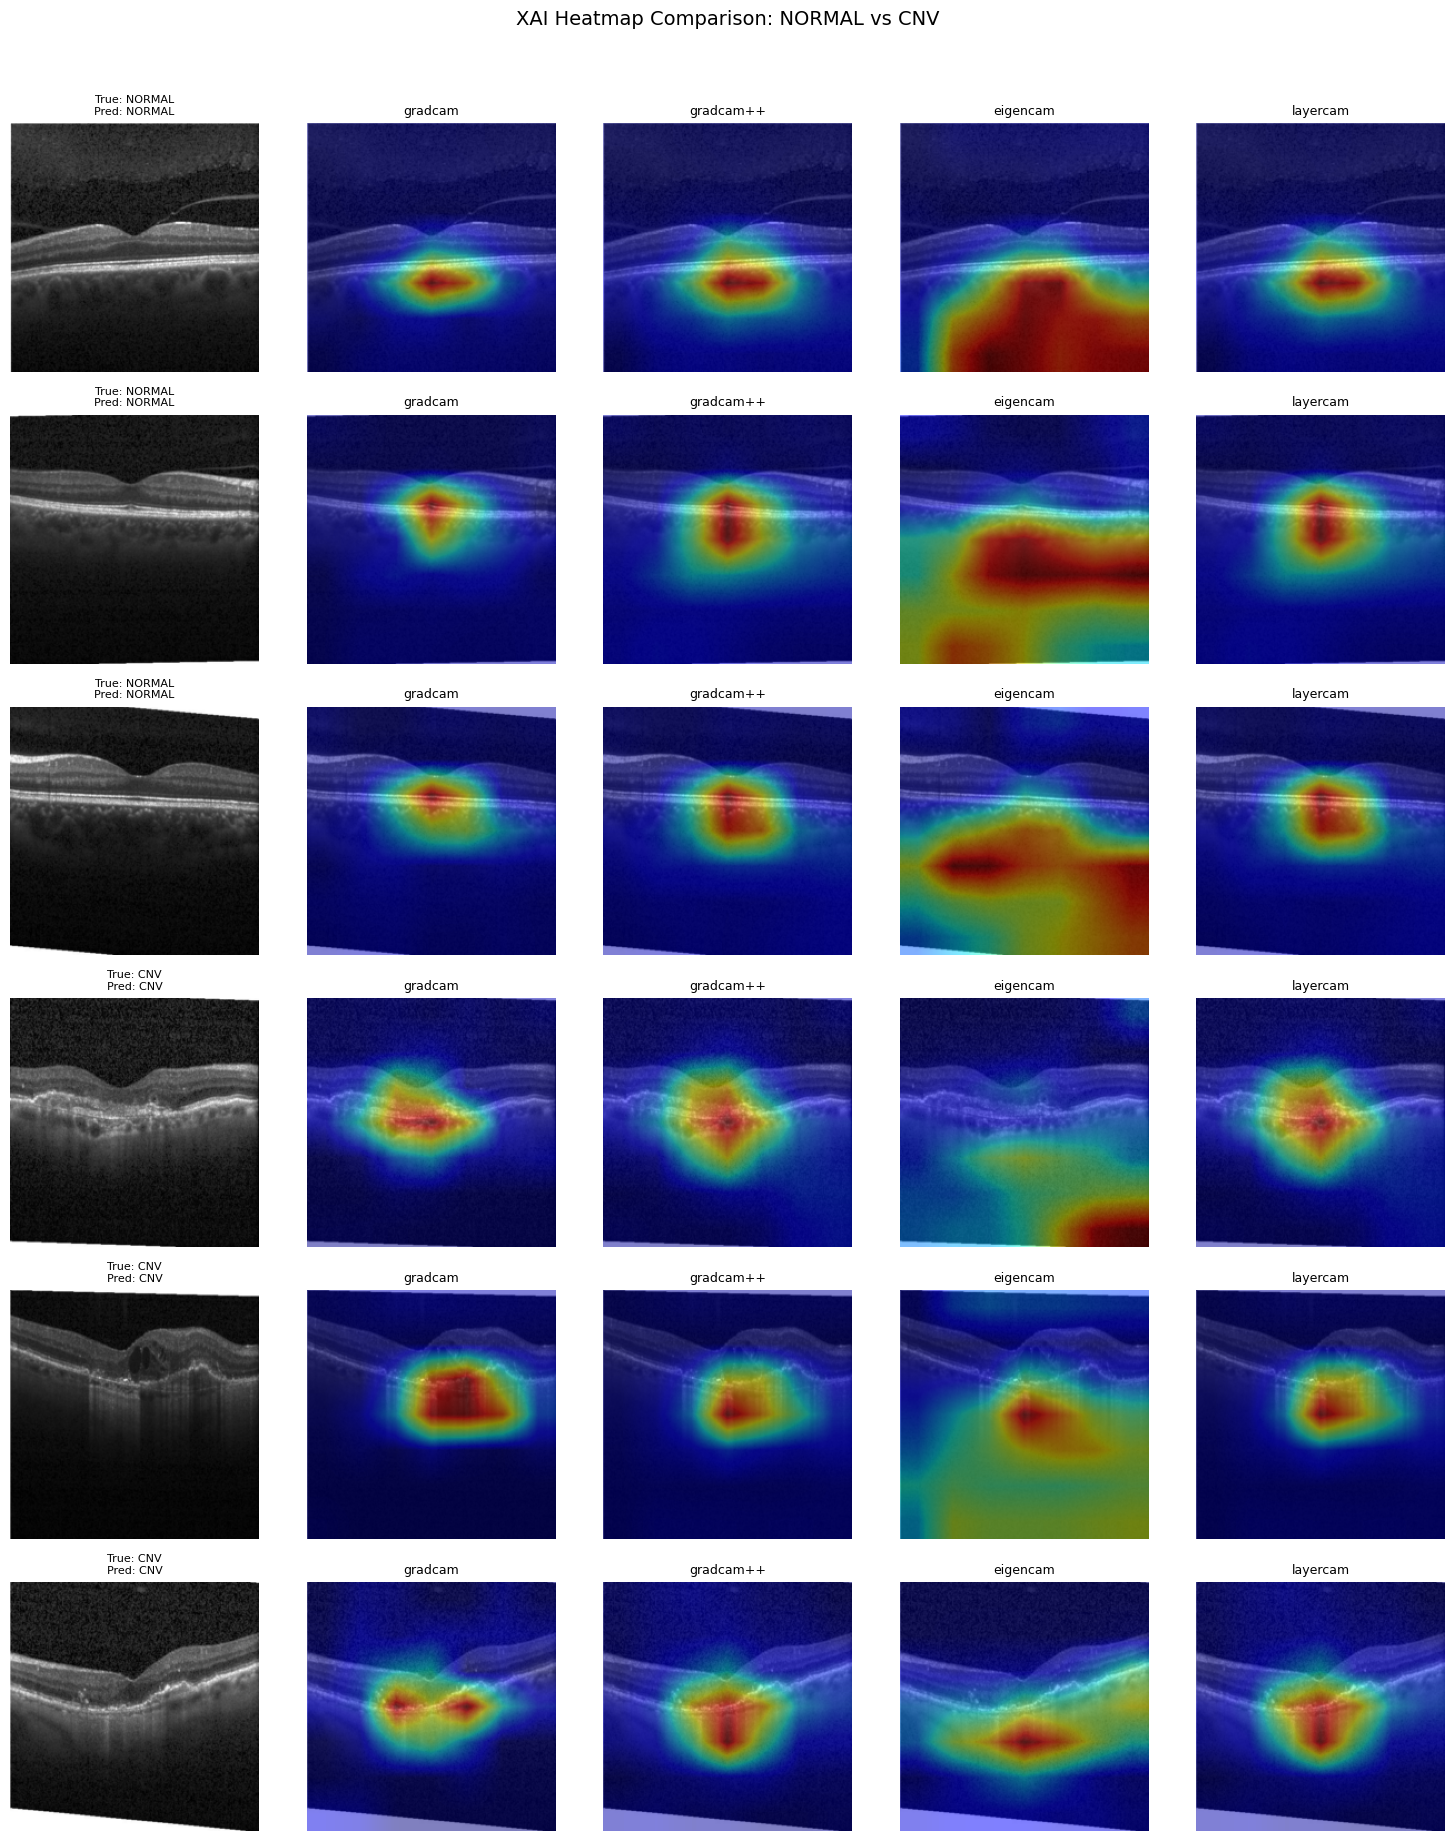

In [10]:
# 각 클래스에서 3장씩 XAI 비교
n_show = 3
fig, axes = plt.subplots(n_show * 2, len(XAI_METHODS) + 1,
                         figsize=(3 * (len(XAI_METHODS) + 1), 3 * n_show * 2))

sample_idx = 0
for cls_label, cls_name in enumerate(CLASS_NAMES):
    cls_samples = [(i, s) for i, s in enumerate(xai_log) if s["true_label"] == cls_name]
    for j in range(min(n_show, len(cls_samples))):
        idx, entry = cls_samples[j]
        img_tensor, label, path = xai_ds[idx]
        raw_img = img_tensor.squeeze().numpy()

        # 원본
        axes[sample_idx, 0].imshow(raw_img, cmap="gray")
        axes[sample_idx, 0].set_title(f"True: {cls_name}\nPred: {entry['pred_label']}", fontsize=8)
        axes[sample_idx, 0].axis("off")

        # 각 XAI method
        for m_idx, method in enumerate(XAI_METHODS):
            npy_path = os.path.join(XAI_OUTPUT_DIR, method,
                                    entry["xai_files"][method].replace(".png", ".npy"))
            cam = np.load(npy_path)
            axes[sample_idx, m_idx + 1].imshow(raw_img, cmap="gray")
            axes[sample_idx, m_idx + 1].imshow(cam, cmap="jet", alpha=0.5)
            axes[sample_idx, m_idx + 1].set_title(method, fontsize=9)
            axes[sample_idx, m_idx + 1].axis("off")

        sample_idx += 1

plt.suptitle("XAI Heatmap Comparison: NORMAL vs CNV", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "xai_comparison_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. XAI 통계 요약

In [11]:
# XAI 히트맵의 활성화 패턴 통계
print("=" * 60)
print(" XAI Activation Statistics by Class & Method")
print("=" * 60)

stats = {method: {cls: [] for cls in CLASS_NAMES} for method in XAI_METHODS}

for entry in xai_log:
    cls = entry["true_label"]
    for method in XAI_METHODS:
        npy_path = os.path.join(XAI_OUTPUT_DIR, method,
                                entry["xai_files"][method].replace(".png", ".npy"))
        cam = np.load(npy_path)
        stats[method][cls].append({
            "mean": float(cam.mean()),
            "std": float(cam.std()),
            "max_region": float((cam > 0.5).sum() / cam.size),  # 고활성 영역 비율
        })

for method in XAI_METHODS:
    print(f"\n  [{method}]")
    for cls in CLASS_NAMES:
        vals = stats[method][cls]
        mean_act = np.mean([v["mean"] for v in vals])
        mean_std = np.mean([v["std"] for v in vals])
        mean_high = np.mean([v["max_region"] for v in vals])
        print(f"    {cls}: mean_activation={mean_act:.4f}, "
              f"std={mean_std:.4f}, high_region_ratio={mean_high:.4f}")

# 저장
with open(os.path.join(OUTPUT_DIR, "xai_statistics.json"), "w") as f:
    json.dump(stats, f, indent=2)
print(f"\nStats saved to {OUTPUT_DIR}/xai_statistics.json")

print(f"\n{'='*60}")
print(f" 실험 1 완료!")
print(f" 출력 디렉토리: {OUTPUT_DIR}/")
print(f" XAI 이미지: {XAI_OUTPUT_DIR}/[method]/*.png")
print(f" XAI 매핑: {XAI_OUTPUT_DIR}/xai_mapping.json")
print(f"{'='*60}")

 XAI Activation Statistics by Class & Method

  [gradcam]
    NORMAL: mean_activation=0.1134, std=0.1693, high_region_ratio=0.0566
    CNV: mean_activation=0.1140, std=0.1771, high_region_ratio=0.0630

  [gradcam++]
    NORMAL: mean_activation=0.1452, std=0.1814, high_region_ratio=0.0712
    CNV: mean_activation=0.1412, std=0.1840, high_region_ratio=0.0740

  [eigencam]
    NORMAL: mean_activation=0.2794, std=0.2459, high_region_ratio=0.2265
    CNV: mean_activation=0.2529, std=0.2428, high_region_ratio=0.1931

  [layercam]
    NORMAL: mean_activation=0.1454, std=0.1815, high_region_ratio=0.0713
    CNV: mean_activation=0.1407, std=0.1839, high_region_ratio=0.0738

Stats saved to exp1_outputs/xai_statistics.json

 실험 1 완료!
 출력 디렉토리: exp1_outputs/
 XAI 이미지: exp1_outputs/xai_images/[method]/*.png
 XAI 매핑: exp1_outputs/xai_images/xai_mapping.json
